<a href="https://colab.research.google.com/github/awrunpatel/django-dashub/blob/main/Seminar_7_Big_data_Text_Mining_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
get_ipython().system('pip install "dask[distributed]"')

In [66]:
from dask.distributed import Client, LocalCluster

# Start a small local cluster for distributed text processing
# This creates multiple workers so incoming text batches can be processed in parallel
cluster = LocalCluster(n_workers=2, threads_per_worker=2, dashboard_address=":8787")

# Connect the client to the cluster so all operations run on distributed workers
client = Client(cluster)

# Display cluster information for students to confirm the distributed environment is active
client

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37683 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:44207
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:37683/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43599'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44243'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:39621 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:39621
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:47762
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:41419 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:41419
IN

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:37683/status,
Dashboard: http://127.0.0.1:37683/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44207,Workers: 0
Dashboard: http://127.0.0.1:37683/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39621,Total threads: 2
Dashboard: http://127.0.0.1:40361/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:43599,


In [67]:
import time
import requests

# This API (https://api.quotable.io/random) provides short, clean, single-sentence quotes.
# The text is varied, human-written, and ideal for teaching tokenisation, streaming behaviour,
# and later analysis tasks such as sentiment trends or pattern detection.

def fetch_text():
    url = "http://api.quotable.io/random"
    response = requests.get(url, timeout=5)
    data = response.json()
    return data["content"]

# Generator that yields micro-batches of real text
def text_stream(batch_size=5):
    while True:
        batch = [fetch_text() for _ in range(batch_size)]
        yield batch
        time.sleep(1)  # simulate real-time arrival

In [68]:
import dask.bag as db

# Function that takes a batch of text messages and distributes them across workers
# Each message becomes an item in a Dask Bag, enabling parallel tokenisation and analysis
def batch_to_bag(batch):
    return db.from_sequence(batch, npartitions=2)

In [64]:
import re

# Basic text cleaning: lowercase, remove punctuation, split into tokens
def clean_and_tokenise(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)   # keep only letters and spaces
    tokens = text.split()
    return tokens

def process_bag(bag):
    return bag.map(clean_and_tokenise)

In [69]:
# Real-time loop: fetch a batch, distribute it, process it, and preview results
# This runs once for demonstration; in a real stream you would loop indefinitely

stream = text_stream(batch_size=5)

# Get one incoming micro-batch of real text
batch = next(stream)

print("Incoming text batch:")
for line in batch:
    print(" ->", line)

# Convert batch to a distributed Dask Bag
bag = batch_to_bag(batch)

# Clean and tokenise in parallel across workers
tokens_bag = process_bag(bag)

tokens_preview = tokens_bag.compute()

print("\nTokenised output:")
for t in tokens_preview:
    print(" ->", t)

Incoming text batch:
 -> Friendship is almost always the union of a part of one mind with the part of another; people are friends in spots.
 -> No enterprise is more likely to succeed than one concealed from the enemy until it is ripe for execution.
 -> If you're going through hell, keep going.
 -> A real friend is one who walks in when the rest of the world walks out.
 -> Never, never, never give up.

Tokenised output:
 -> ['friendship', 'is', 'almost', 'always', 'the', 'union', 'of', 'a', 'part', 'of', 'one', 'mind', 'with', 'the', 'part', 'of', 'another', 'people', 'are', 'friends', 'in', 'spots']
 -> ['no', 'enterprise', 'is', 'more', 'likely', 'to', 'succeed', 'than', 'one', 'concealed', 'from', 'the', 'enemy', 'until', 'it', 'is', 'ripe', 'for', 'execution']
 -> ['if', 'youre', 'going', 'through', 'hell', 'keep', 'going']
 -> ['a', 'real', 'friend', 'is', 'one', 'who', 'walks', 'in', 'when', 'the', 'rest', 'of', 'the', 'world', 'walks', 'out']
 -> ['never', 'never', 'never', 'giv

In [70]:
info = client.scheduler_info()

print("Number of workers:", len(info["workers"]))
for wid, w in info["workers"].items():
    print(f"Worker {wid[:6]} | Threads: {w['nthreads']} | Memory: {w['memory_limit'] / 1e9:.2f} GB")

Number of workers: 2
Worker tcp:// | Threads: 2 | Memory: 6.80 GB
Worker tcp:// | Threads: 2 | Memory: 6.80 GB


In [71]:
from collections import Counter

# Count tokens within each message, then combine counts across the distributed batch
def count_words(tokens_bag):
    per_message_counts = tokens_bag.map(lambda tokens: Counter(tokens))

    # Reduce all Counters into one combined Counter
    total_counts = per_message_counts.fold(lambda x, y: x + y)

    return total_counts

In [72]:
# Compute distributed word counts for the current batch
word_counts = count_words(tokens_bag).compute()

# Show the most common words in this micro‑batch
print("Top words in this batch:")
for word, count in word_counts.most_common(10):
    print(f" -> {word}: {count}")

Top words in this batch:
 -> the: 5
 -> is: 4
 -> of: 4
 -> one: 3
 -> never: 3
 -> a: 2
 -> part: 2
 -> in: 2
 -> going: 2
 -> walks: 2


In [73]:
# Running counter that keeps track of word frequencies across all processed batches
running_counts = Counter()

# Function that updates the running counter with the latest batch results
def update_running_counts(batch_counts):
    global running_counts
    running_counts.update(batch_counts)
    return running_counts

In [74]:

for i in range(3):   # adjust this number to stream more batches
    print(f"\n--- Batch {i+1} ---")

    # Fetch the next micro-batch of real text
    batch = next(stream)

    print("Incoming text:")
    for line in batch:
        print(" ->", line)

    # Distribute the batch across workers
    bag = batch_to_bag(batch)

    # Clean and tokenise in parallel
    tokens_bag = process_bag(bag)

    # Count words in this batch
    batch_counts = count_words(tokens_bag).compute()

    print("\nTop words in this batch:")
    for word, count in batch_counts.most_common(5):
        print(f" -> {word}: {count}")

    # Update running totals
    updated = update_running_counts(batch_counts)

    print("\nRunning totals so far:")
    for word, count in updated.most_common(5):
        print(f" -> {word}: {count}")


--- Batch 1 ---
Incoming text:
 -> Happiness is the reward we get for living to the highest right we know.
 -> I never worry about action, but only inaction.
 -> The older I get the more wisdom I find in the ancient rule of taking first things first. A process which often reduces the most complex human problem to a manageable proportion.
 -> God gave us the gift of life; it is up to us to give ourselves the gift of living well.
 -> Knowledge comes, but wisdom lingers. It may not be difficult to store up in the mind a vast quantity of facts within a comparatively short time, but the ability to form judgments requires the severe discipline of hard work and the tempering heat of experience and maturity.

Top words in this batch:
 -> the: 12
 -> to: 6
 -> of: 6
 -> a: 4
 -> i: 3

Running totals so far:
 -> the: 12
 -> to: 6
 -> of: 6
 -> a: 4
 -> i: 3

--- Batch 2 ---
Incoming text:
 -> Wisdom cannot come by railroad or automobile or airplane or be hurried up by telegraph or telephone.
 -

How Dask Processes Each Incoming Batch
Dask does not send the whole batch to every worker. Instead:
- A batch arrives as a normal Python list in the notebook.
- Dask splits the batch into partitions (small slices of the data).
- Each partition is sent to a different worker when computation starts.
- Workers only process their own slice, not the full batch.
- After processing, workers return partial results, and the scheduler combines them.
Key idea:
Workers never store or duplicate the full batch — they only handle the partition assigned to them


In [ ]:
import matplotlib.pyplot as plt

# Track history of top words across batches
history = {}

# Reset running counts for a clean plot
running_counts = Counter()

for i in range(3):   # adjust number of batches
    print(f"\n--- Batch {i+1} ---")

    batch = next(stream)

    # Distribute and process
    bag = batch_to_bag(batch)
    tokens_bag = process_bag(bag)
    batch_counts = count_words(tokens_bag).compute()

    # Update running totals
    running_counts.update(batch_counts)

    # Track top words over time
    top_words = running_counts.most_common(5)
    for word, count in top_words:
        history.setdefault(word, []).append(count)

# Plot drift
plt.figure(figsize=(10, 5))
for word, counts in history.items():
    plt.plot(counts, marker='o', label=word)

plt.title("Word-Frequency Drift Across Streaming Batches")
plt.xlabel("Batch Number")
plt.ylabel("Cumulative Count")
plt.legend()
plt.grid(True)
plt.show()


--- Batch 1 ---

--- Batch 2 ---

--- Batch 3 ---


In [ ]:

# Reset running counts and history
running_counts = Counter()
history = {}
num_batches = 5

for i in range(num_batches):
    print(f"\n--- Batch {i+1} ---")

    batch = next(stream)

    # Process batch
    bag = batch_to_bag(batch)
    tokens_bag = process_bag(bag)
    batch_counts = count_words(tokens_bag).compute()

    # Update running totals
    running_counts.update(batch_counts)

    # Select a fixed set of words to track (top words after this batch)
    if i == 0:
        tracked_words = [w for w, _ in running_counts.most_common(5)]

    # Record counts for tracked words (fill missing with zero)
    for word in tracked_words:
        history.setdefault(word, []).append(running_counts.get(word, 0))

# Plot stable drift
plt.figure(figsize=(10, 5))
for word, counts in history.items():
    plt.plot(range(1, num_batches + 1), counts, marker='o', label=word)

plt.title("Stable Word-Frequency Drift Across Streaming Batches")
plt.xlabel("Batch Number")
plt.ylabel("Cumulative Count")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!pip install vaderSentiment


--- Batch 1 ---
Sentence-level sentiment:
 • The price of greatness is responsibility.  -->  0.000 (neutral)
 • Being entirely honest with oneself is a good exercise.  -->  0.757 (positive)
 • A dream is your creative vision for your life in the future. You must break out of your current comfort zone and become comfortable with the unfamiliar and the unknown.  -->  0.893 (positive)
 • Be slow to fall into friendship; but when thou art in, continue firm and constant.  -->  0.238 (positive)
 • Quality is never an accident; it is always the result of intelligent effort.  -->  0.676 (positive)

Average sentiment: 0.513 (positive)

--- Batch 2 ---
Sentence-level sentiment:
 • Business, you know, may bring you money, but friendship hardly ever does.  -->  0.593 (positive)
 • In the sweetness of friendship let there be laughter and sharing of pleasures. For in the dew of little things the heart finds its morning and is refreshed.  -->  0.958 (positive)
 • A man sees in the world what he carr

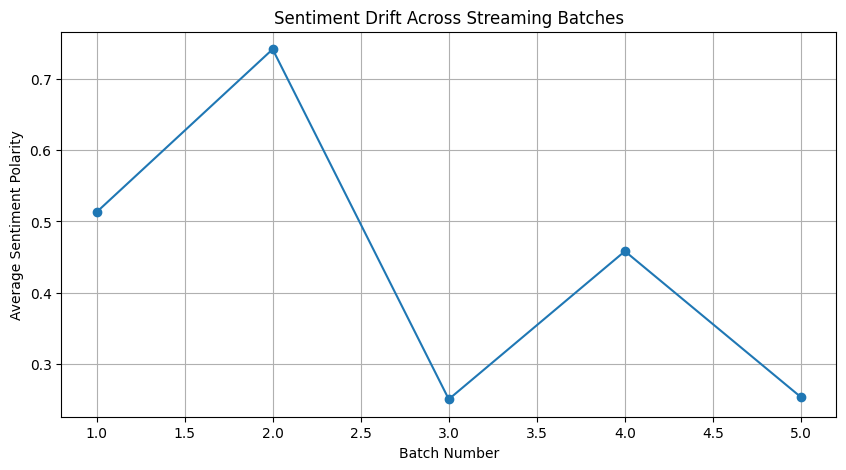

In [63]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt


analyzer = SentimentIntensityAnalyzer()

def sentiment_label(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

def batch_sentiment(batch):
    scores = []
    for line in batch:
        polarity = analyzer.polarity_scores(line)["compound"]
        scores.append(polarity)
    return sum(scores) / len(scores) if scores else 0.0

# Track sentiment over time
sentiment_history = []
num_batches = 5

for i in range(num_batches):
    print(f"\n--- Batch {i+1} ---")

    batch = next(stream)

    # Show sentence-level sentiment for teaching clarity
    print("Sentence-level sentiment:")
    for line in batch:
        score = analyzer.polarity_scores(line)["compound"]
        label = sentiment_label(score)
        print(f" • {line}  -->  {score:.3f} ({label})")

    # Compute batch-level average sentiment
    avg_sent = batch_sentiment(batch)
    sentiment_history.append(avg_sent)

    print(f"\nAverage sentiment: {avg_sent:.3f} ({sentiment_label(avg_sent)})")

# Plot sentiment drift
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_batches + 1), sentiment_history, marker='o')
plt.title("Sentiment Drift Across Streaming Batches")
plt.xlabel("Batch Number")
plt.ylabel("Average Sentiment Polarity")
plt.grid(True)
plt.show()